In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
#os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [2]:
import keras
import numpy as np
import torchvision
from sklearn.model_selection import train_test_split


# MNIST dataset

transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                            train=False,
                                            transform=transform)

X_train = train_dataset.data
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)


input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))


/home/zab/Git/ML_Course_PT/Hometasks/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment(X, y, augmentation_factor=5):

    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2],
        shear_range=10,
        fill_mode='reflect',
        dtype=X.dtype
    )

    # Создаем расширенные массивы
    augmented_X = []
    augmented_y = []

    # Добавляем оригинальные данные
    augmented_X.append(X)
    augmented_y.append(y)

    for i in range(augmentation_factor):
        print(f"Генерация батча {i+1}/{augmentation_factor}...")
        X_augmented = []
        y_augmented = []

        for x_batch, y_batch in datagen.flow(X, y, batch_size=32, shuffle=False):
            X_augmented.append(x_batch)
            y_augmented.append(y_batch)
            if len(X_augmented) * 32 >= len(X):
                break

        X_augmented = np.concatenate(X_augmented, axis=0)[:len(X)]
        y_augmented = np.concatenate(y_augmented, axis=0)[:len(y)]

        augmented_X.append(X_augmented)
        augmented_y.append(y_augmented)

    X_final = np.concatenate(augmented_X, axis=0)
    y_final = np.concatenate(augmented_y, axis=0)

    indices = np.random.permutation(len(X_final))
    X_final = X_final[indices]
    y_final = y_final[indices]

    return X_final, y_final

X_train, y_train = augment(X_train, y_train)


Генерация батча 1/5...
Генерация батча 2/5...
Генерация батча 3/5...
Генерация батча 4/5...
Генерация батча 5/5...


In [4]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Размер тренировочных данных: {X_train.shape}")
print(f"Размер валидационных данных: {X_val.shape}")
print(f"Размер тестовых данных: {X_test.shape}")
print(f"Метки классов: {np.unique(y_train)}")


Размер тренировочных данных: (270000, 32, 32, 3)
Размер валидационных данных: (5000, 32, 32, 3)
Размер тестовых данных: (10000, 32, 32, 3)
Метки классов: [0 1 2 3 4 5 6 7 8 9]


In [5]:
import gc
import tensorflow as tf
from keras.src.optimizers import AdamW
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau
from matplotlib import pyplot as plt

def categorical_crossentropy_with_label_smoothing(y_true, y_pred, smoothing=0.1):
    confidence = 1.0 - smoothing
    y_true_smooth = y_true * confidence + smoothing / tf.cast(tf.shape(y_true)[-1], tf.float32)
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

def train_and_evaluate_model(model, epochs=100, batch_size=256):
    gc.collect()
    tf.keras.backend.clear_session()

    # Сброс метаданных GPU
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
        except:
            pass

    model.compile(
        optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=categorical_crossentropy_with_label_smoothing,
        metrics=['accuracy']
    )


    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=0.1e-7, mode='max', verbose=1),
    ]

    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\nТестовая точность: {test_accuracy:.4f}")
    print(f"Тестовая потеря: {test_loss:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Точность модели')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Точность')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Потери модели')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Потери')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return model


Epoch 1/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 64s 50ms/step - accuracy: 0.5989 - loss: 1.1165 - val_accuracy: 0.6314 - val_loss: 1.2598 - learning_rate: 0.0010
Epoch 2/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.7862 - loss: 0.6310 - val_accuracy: 0.7992 - val_loss: 0.6038 - learning_rate: 0.0010
Epoch 3/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.8376 - loss: 0.4817 - val_accuracy: 0.8784 - val_loss: 0.3573 - learning_rate: 0.0010
Epoch 4/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.8689 - loss: 0.3893 - val_accuracy: 0.8440 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 5/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.8901 - loss: 0.3243 - val_accuracy: 0.8736 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 6/100
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9052 - loss: 0.2782
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - ac

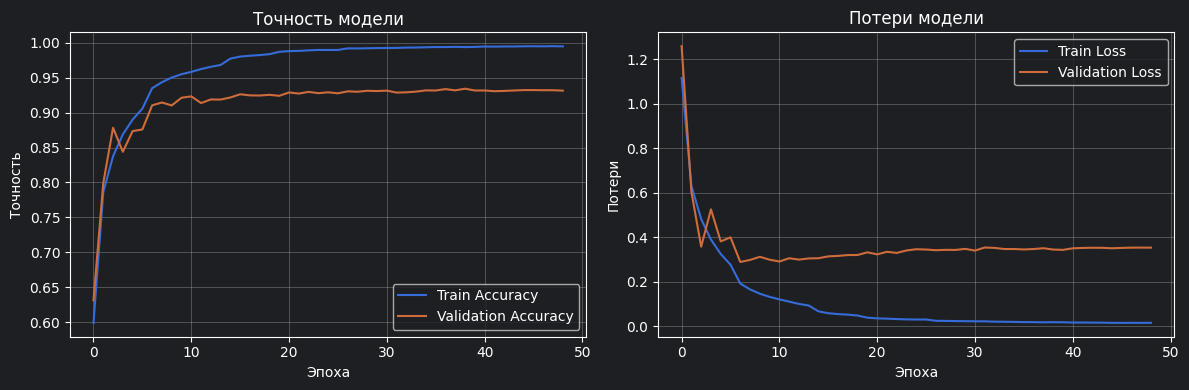

In [11]:
# TASK 6: free lance

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Начальный блок
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)

    # Блок 1: 32 -> 64
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Блок 2: 64 -> 128
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Блок 3: 128 -> 256
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # Блок 4: дополнительный с меньшим пулингом
    x = layers.Conv2D(512, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Классификатор
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

model = train_and_evaluate_model(build_model())



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


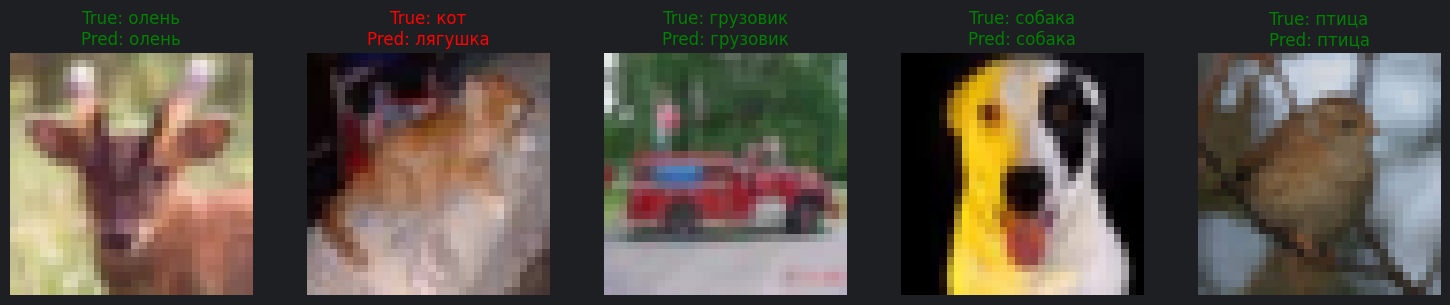

In [8]:
class_names = ['самолет', 'автомобиль', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Функция для визуализации предсказаний
def show_predictions(model, x_test, y_test, num_images=5):
    indices = np.random.choice(len(x_test), num_images, replace=False)

    predictions = model.predict(x_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = y_test[indices]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(indices):
        axes[i].imshow(x_test[idx])
        axes[i].axis('off')

        color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
        title = f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}"
        axes[i].set_title(title, color=color)

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)